**15.3. Project 3 - Credit Card Fraud Detection**

**Dataset:** `creditcard.csv`

Highly Imbalanced Dataset

**Dataset reference:** https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

**1. Setup**

In [1]:
# install the required libraries
%pip install -q numpy pandas matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# importing the dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    average_precision_score,
)

In [3]:
# configurations
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")

RANDOM_STATE = 42

**2. Load data**

In [4]:
df = pd.read_csv("creditcard.csv")

**3. Exploratory Data Analysis (EDA)**

In [5]:
df.shape

(284807, 31)

In [6]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.000,-1.360,-0.073,2.536,1.378,-0.338,0.462,0.240,0.099,0.364,0.091,-0.552,-0.618,-0.991,-0.311,1.468,-0.470,0.208,0.026,0.404,0.251,-0.018,0.278,-0.110,0.067,0.129,-0.189,0.134,-0.021,149.620,0
1,0.000,1.192,0.266,0.166,0.448,0.060,-0.082,-0.079,0.085,-0.255,-0.167,1.613,1.065,0.489,-0.144,0.636,0.464,-0.115,-0.183,-0.146,-0.069,-0.226,-0.639,0.101,-0.340,0.167,0.126,-0.009,0.015,2.690,0
2,1.000,-1.358,-1.340,1.773,0.380,-0.503,1.800,0.791,0.248,-1.515,0.208,0.625,0.066,0.717,-0.166,2.346,-2.890,1.110,-0.121,-2.262,0.525,0.248,0.772,0.909,-0.689,-0.328,-0.139,-0.055,-0.060,378.660,0
3,1.000,-0.966,-0.185,1.793,-0.863,-0.010,1.247,0.238,0.377,-1.387,-0.055,-0.226,0.178,0.508,-0.288,-0.631,-1.060,-0.684,1.966,-1.233,-0.208,-0.108,0.005,-0.190,-1.176,0.647,-0.222,0.063,0.061,123.500,0
4,2.000,-1.158,0.878,1.549,0.403,-0.407,0.096,0.593,-0.271,0.818,0.753,-0.823,0.538,1.346,-1.120,0.175,-0.451,-0.237,-0.038,0.803,0.409,-0.009,0.798,-0.137,0.141,-0.206,0.502,0.219,0.215,69.990,0


Class:
- 0 -> non-fraud
- 1 -> fraud

In [7]:
# basic overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [8]:
# missing values
df.isna().sum().sort_values(ascending=False)

Time      0
V16       0
Amount    0
V28       0
V27       0
V26       0
V25       0
V24       0
V23       0
V22       0
V21       0
V20       0
V19       0
V18       0
V17       0
V15       0
V1        0
V14       0
V13       0
V12       0
V11       0
V10       0
V9        0
V8        0
V7        0
V6        0
V5        0
V4        0
V3        0
V2        0
Class     0
dtype: int64

In [9]:
# quick checks for encoded missing values
for col in df.columns:
    print(df[col].value_counts().head(10))

Time
163152.000    36
64947.000     26
68780.000     25
3767.000      21
3770.000      20
3750.000      19
19912.000     19
140347.000    19
128860.000    19
143083.000    18
Name: count, dtype: int64
V1
2.056     77
1.246     77
2.053     62
1.302     60
2.040     53
2.085     48
1.333     45
1.018     40
1.335     39
-0.303    36
Name: count, dtype: int64
V2
-0.327    77
0.167     77
0.090     62
-0.607    60
-0.147    53
0.393     48
0.389     45
1.037     40
0.331     39
0.447     36
Name: count, dtype: int64
V3
-2.752    77
0.488     77
-1.682    62
-0.682    60
-2.956    53
-4.508    48
-2.166    45
-1.690    40
-2.058    39
-0.496    36
Name: count, dtype: int64
V4
-0.842    77
0.635     77
0.454     62
-1.905    60
-0.578    53
-0.312    48
-0.307    45
1.315     40
-0.346    39
-3.215    36
Name: count, dtype: int64
V5
2.463     77
-0.563    77
0.298     62
1.327     60
2.609     53
3.510     48
2.641     45
1.698     40
2.583     39
2.705     36
Name: count, dtype: int64
V6
3

In [10]:
# duplicates
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()
print("Number of duplicate rows:", num_duplicates)

# (optional) drop duplicates if present
# df = df.drop_duplicates()
# print("Shape after dropping duplicates:", df.shape)


Number of duplicate rows: 1081


In [11]:
# target distribution
print(df["Class"].value_counts())
print("-"*50)
print(df["Class"].value_counts(normalize=True) * 100)

Class
0    284315
1       492
Name: count, dtype: int64
--------------------------------------------------
Class
0   99.827
1    0.173
Name: proportion, dtype: float64


**NOTE: Data is Highly Imbalanced**

In [12]:
# imbalance ratio
n_fraud = (df["Class"] == 1).sum()
n_nonfraud = (df["Class"] == 0).sum()
print("\nImbalance ratio (non-fraud : fraud) =", round(n_nonfraud / max(n_fraud, 1), 2))


Imbalance ratio (non-fraud : fraud) = 577.88


**Inference: 1 fraud transaction for 577 non-fraud transactions**

In [13]:
# descriptive stats for key columns
df[["Time", "Amount"]].describe()

,Time,Amount
count,284807.000,284807.000
mean,94813.860,88.350
std,47488.146,250.120
min,0.000,0.000
25%,54201.500,5.600
50%,84692.000,22.000
75%,139320.500,77.165
max,172792.000,25691.160


In [14]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000
mean,94813.860,0.000,0.000,-0.000,0.000,0.000,0.000,-0.000,0.000,-0.000,0.000,0.000,-0.000,0.000,0.000,0.000,0.000,-0.000,0.000,0.000,0.000,0.000,-0.000,0.000,0.000,0.000,0.000,-0.000,-0.000,88.350,0.002
std,47488.146,1.959,1.651,1.516,1.416,1.380,1.332,1.237,1.194,1.099,1.089,1.021,0.999,0.995,0.959,0.915,0.876,0.849,0.838,0.814,0.771,0.735,0.726,0.624,0.606,0.521,0.482,0.404,0.330,250.120,0.042
min,0.000,-56.408,-72.716,-48.326,-5.683,-113.743,-26.161,-43.557,-73.217,-13.434,-24.588,-4.797,-18.684,-5.792,-19.214,-4.499,-14.130,-25.163,-9.499,-7.214,-54.498,-34.830,-10.933,-44.808,-2.837,-10.295,-2.605,-22.566,-15.430,0.000,0.000
25%,54201.500,-0.920,-0.599,-0.890,-0.849,-0.692,-0.768,-0.554,-0.209,-0.643,-0.535,-0.762,-0.406,-0.649,-0.426,-0.583,-0.468,-0.484,-0.499,-0.456,-0.212,-0.228,-0.542,-0.162,-0.355,-0.317,-0.327,-0.071,-0.053,5.600,0.000
50%,84692.000,0.018,0.065,0.180,-0.020,-0.054,-0.274,0.040,0.022,-0.051,-0.093,-0.033,0.140,-0.014,0.051,0.048,0.066,-0.066,-0.004,0.004,-0.062,-0.029,0.007,-0.011,0.041,0.017,-0.052,0.001,0.011,22.000,0.000
75%,139320.500,1.316,0.804,1.027,0.743,0.612,0.399,0.570,0.327,0.597,0.454,0.740,0.618,0.663,0.493,0.649,0.523,0.400,0.501,0.459,0.133,0.186,0.529,0.148,0.440,0.351,0.241,0.091,0.078,77.165,0.000
max,172792.000,2.455,22.058,9.383,16.875,34.802,73.302,120.589,20.007,15.595,23.745,12.019,7.848,7.127,10.527,8.878,17.315,9.254,5.041,5.592,39.421,27.203,10.503,22.528,4.585,7.520,3.517,31.612,33.848,25691.160,1.000


**Data Visualization**

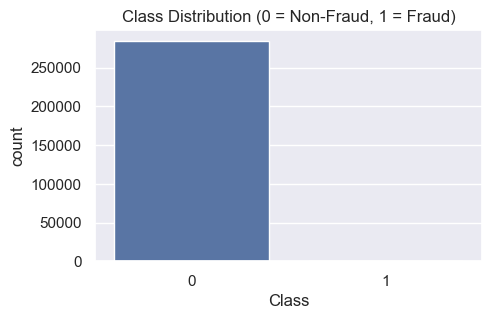

In [15]:
# visualize class imbalance
plt.figure(figsize=(5, 3))
sns.countplot(x="Class", data=df)
plt.title("Class Distribution (0 = Non-Fraud, 1 = Fraud)")
plt.show()

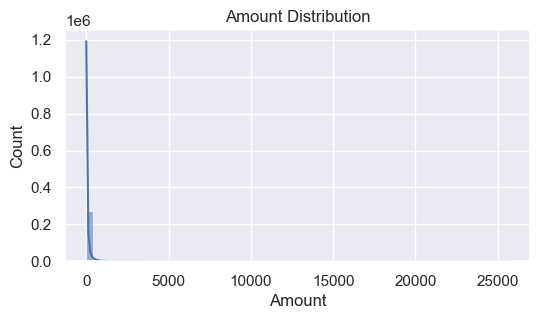

In [16]:
# Amount distribution (raw)
plt.figure(figsize=(6, 3))
sns.histplot(df["Amount"], bins=60, kde=True)
plt.title("Amount Distribution")
plt.show()

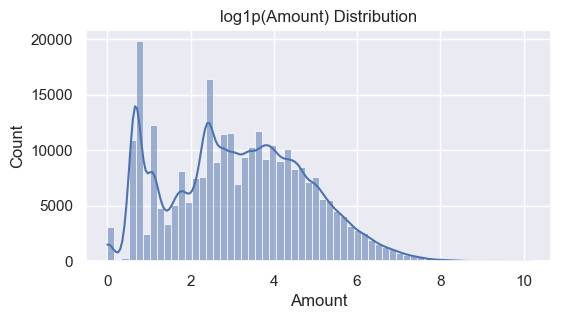

In [17]:
# Amount distribution (raw + log1p)
plt.figure(figsize=(6, 3))
sns.histplot(np.log1p(df["Amount"]), bins=60, kde=True)
plt.title("log1p(Amount) Distribution")
plt.show()

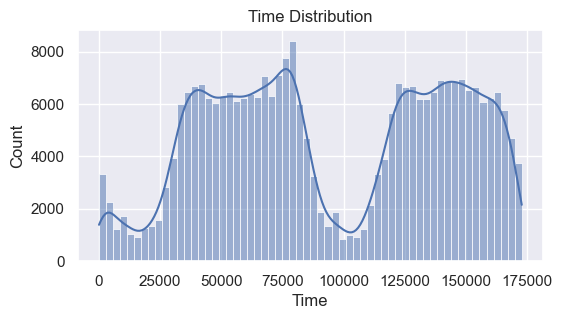

In [18]:
# Time distribution
plt.figure(figsize=(6, 3))
sns.histplot(df["Time"], bins=60, kde=True)
plt.title("Time Distribution")
plt.show()

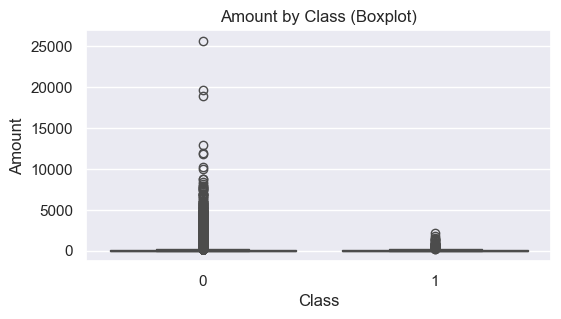

In [19]:
# Amount by class (helps intuition)
plt.figure(figsize=(6, 3))
sns.boxplot(x="Class", y="Amount", data=df)
plt.title("Amount by Class (Boxplot)")
plt.show()

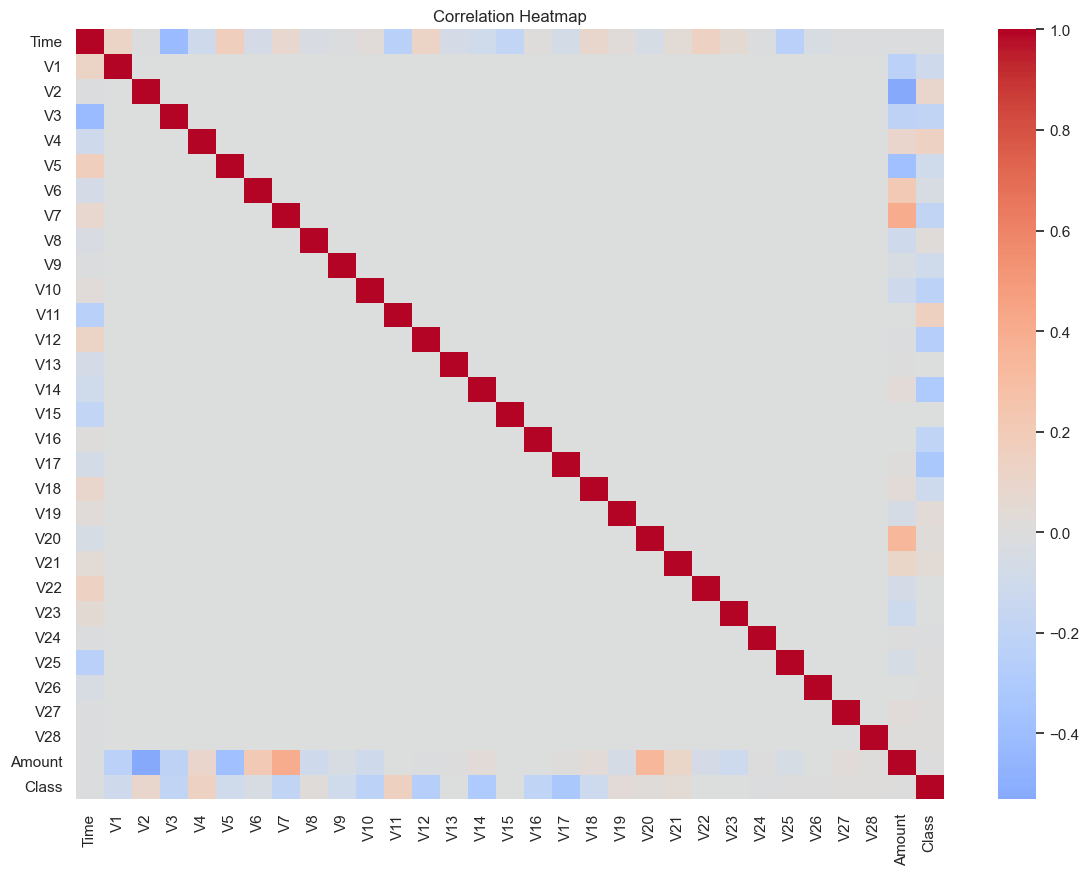

In [20]:
# correlation heatmap (can be heavy but useful)
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

**There are no highly correlated columns (probably beacuase of PCA applied columns)**

In [21]:
# correlation with target (top signals)
corr_target = df.corr(numeric_only=True)["Class"].sort_values(ascending=False)
corr_target.head(5), corr_target.tail(5)

(Class   1.000
 V11     0.155
 V4      0.133
 V2      0.091
 V21     0.040
 Name: Class, dtype: float64,
 V16   -0.197
 V10   -0.217
 V12   -0.261
 V14   -0.303
 V17   -0.326
 Name: Class, dtype: float64)

**4. Data Preprocessing**

In [22]:
# Add log1p(Amount) for stability
df["Amount_log1p"] = np.log1p(df["Amount"])

In [23]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class', 'Amount_log1p'],
      dtype='object')

In [24]:
# separate features and target
X = df.drop(columns=["Class", "Amount"])   # removing AMount as we have Amount_log1p
y = df["Class"]

In [25]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

In [26]:
print("Dataset Shape:", X.shape)
print("Training Data Shape:", X_train.shape)
print("Test Data Shape:", X_test.shape)

Dataset Shape: (284807, 30)
Training Data Shape: (227845, 30)
Test Data Shape: (56962, 30)


**5. Baseline Model**

In [27]:
base_pipeline = Pipeline(
    [
        ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]
)

In [28]:
# train the model
base_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If f

In [29]:
y_base_train_pred = base_pipeline.predict(X_train)
y_base_test_pred = base_pipeline.predict(X_test)

In [30]:
base_train_acc = round(accuracy_score(y_train, y_base_train_pred)*100, 2)
base_test_acc = round(accuracy_score(y_test, y_base_test_pred)*100, 2)

In [31]:
print("Baseline Train Accuracy:", base_train_acc)
print("Baseline Test Accuracy:", base_test_acc)

Baseline Train Accuracy: 100.0
Baseline Test Accuracy: 99.91


In [32]:
print("Train - Classification Report")
print(classification_report(y_train, y_base_train_pred))

Train - Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    227451
           1       1.00      1.00      1.00       394

    accuracy                           1.00    227845
   macro avg       1.00      1.00      1.00    227845
weighted avg       1.00      1.00      1.00    227845



In [33]:
print("Test - Classification Report")
print(classification_report(y_test, y_base_test_pred))

Test - Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.75      0.74      0.75        98

    accuracy                           1.00     56962
   macro avg       0.88      0.87      0.87     56962
weighted avg       1.00      1.00      1.00     56962



**Note: Accuracy score is not reliable because of class imbalance**

In [34]:
# average precision score (or) pr-auc - training data
y_train_prob = base_pipeline.predict_proba(X_train)[:, 1]
print("Training Average Precision Score:", average_precision_score(y_train, y_train_prob))

Training Average Precision Score: 1.0


In [35]:
# average precision score (or) pr-auc - test data
y_test_prob = base_pipeline.predict_proba(X_test)[:, 1]
print("Test Average Precision Score:", average_precision_score(y_test, y_test_prob))

Test Average Precision Score: 0.5610321985726947


**6. Model & optimization**

In [36]:
k = 5
cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

In [37]:
models = {
    "dt_balanced": Pipeline(
        [
            ("model", DecisionTreeClassifier(
                random_state=RANDOM_STATE,
                class_weight="balanced"
            ))
        ]
    ),
    "hgb_balanced": Pipeline(
        [
            ("model", HistGradientBoostingClassifier(
                random_state=RANDOM_STATE,
                class_weight="balanced"
            ))
        ]
    ),
    "rf_balanced": Pipeline(
        [
            ("model", RandomForestClassifier(
                random_state=RANDOM_STATE,
                class_weight="balanced_subsample"
            ))
        ]
    )
}

In [38]:
for name, m in models.items():

    pr_auc_scores = []

    for tr_idx, te_idx, in cv.split(X_train, y_train):
        X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
        y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]

        m.fit(X_tr, y_tr)
        pred_prob = m.predict_proba(X_te)[:, 1]

        pr_auc_scores.append(average_precision_score(y_te, pred_prob))

    print("Model name:", name)
    print("PR-AUC values:", pr_auc_scores)
    print("CV PR-AUC mean:", round(float(np.mean(pr_auc_scores)), 4))

# cross validation is a more reliable metric

Model name: dt_balanced
PR-AUC values: [0.5007266812564823, 0.4830774702828517, 0.5797304220740939, 0.5880053883273093, 0.5312714890725482]
CV PR-AUC mean: 0.5366
Model name: hgb_balanced
PR-AUC values: [0.7650653511464124, 0.7426863047121038, 0.6961437658687323, 0.7842427747774444, 0.7429545175433017]
CV PR-AUC mean: 0.7462
Model name: rf_balanced
PR-AUC values: [0.8472364033066033, 0.8091652726680121, 0.8213001553557148, 0.8697119534156066, 0.8352263576229708]
CV PR-AUC mean: 0.8365


**Best Model as per model selection process:** Random Forest Classifier

**Hyper parameter tuning for Random Forest Classifier**

In [39]:
rfc_pipeline = Pipeline([
    ("model", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ))
])

In [40]:
# hyperparameter tuining - Random Forest Classifier
param_dist = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_leaf": [1, 5, 10, 20],
    "model__max_features": ["sqrt", "log2", 0.5]
}

In [41]:
# random search
random_search = RandomizedSearchCV(
    estimator=rfc_pipeline,
    param_distributions=param_dist,
    n_iter=10,
    scoring="average_precision",  # PR-AUC
    cv=cv,
    verbose=True
)

In [42]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [1, 5, ...], 'model__n_estimators': [200, 300, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-

In [47]:
print("Best CV PR-AUC:", round(random_search.best_score_, 4))
print("Best params:", random_search.best_params_)

Best CV PR-AUC: 0.8476
Best params: {'model__n_estimators': 500, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 30}


**7. Re-train with best parameters**

In [48]:
best_rfc = Pipeline(
    [
        ("model", RandomForestClassifier(
            n_estimators=500,
            min_samples_leaf=1,
            max_features="log2",
            max_depth=30,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced_subsample"
        ))
    ]
)

In [49]:
# train best rfc
best_rfc.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If fl

**8. Model Evaluation**

In [50]:
# training data prediction
y_train_pred = best_rfc.predict(X_train)

In [51]:
train_acc = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {round(train_acc*100, 2)} %")

Training Accuracy: 100.0 %


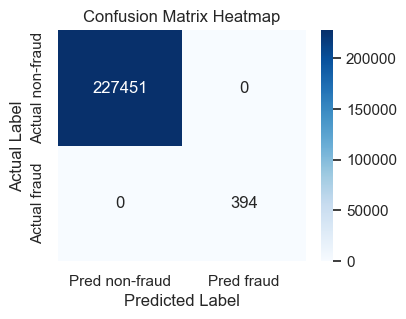

In [53]:
# confusion matrix
cm = confusion_matrix(y_train, y_train_pred)

plt.figure(figsize=(4,3))
# heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred non-fraud", "Pred fraud"],
    yticklabels=["Actual non-fraud", "Actual fraud"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [54]:
print("Training Classification report")
print(classification_report(y_train, y_train_pred))

Training Classification report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    227451
           1       1.00      1.00      1.00       394

    accuracy                           1.00    227845
   macro avg       1.00      1.00      1.00    227845
weighted avg       1.00      1.00      1.00    227845



In [56]:
train_proba = best_rfc.predict_proba(X_train)[:, 1]
print("Train PR-AUC:", round(average_precision_score(y_train, train_proba), 4))

Train PR-AUC: 1.0


In [57]:
# test data prediction
y_test_pred = best_rfc.predict(X_test)

In [58]:
test_acc = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {round(test_acc*100, 2)} %")

Test Accuracy: 99.95 %


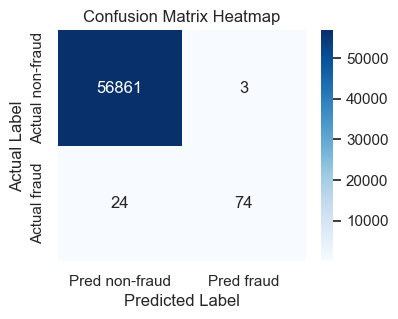

In [60]:
# confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(4,3))
# heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred non-fraud", "Pred fraud"],
    yticklabels=["Actual non-fraud", "Actual fraud"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [61]:
print("Test Classification report")
print(classification_report(y_test, y_test_pred))

Test Classification report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.76      0.85        98

    accuracy                           1.00     56962
   macro avg       0.98      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [62]:
test_proba = best_rfc.predict_proba(X_test)[:, 1]
print("Test PR-AUC:", round(average_precision_score(y_test, test_proba), 4))

Test PR-AUC: 0.8679


**9. Build a predictive system**

In [63]:
def predict_class(input_features):
    input_df = pd.DataFrame(
        [input_features],
        columns=X_train.columns
    )
    # get prediction from trained model
    prediction = best_rfc.predict(input_df)
    print("Model prediction:", prediction)
    if prediction[0] == 1:
        print("Fraud Transaction detected ❌")
    else:
        print("Non-Fraud Transaction ✅")

In [64]:
X_test.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount_log1p
263020,160760.000,-0.674,1.408,-1.111,-1.328,1.389,-1.308,1.886,-0.614,0.312,0.651,-0.858,-0.230,-0.200,0.266,-0.047,-0.741,-0.606,-0.393,-0.163,0.394,0.080,0.810,-0.224,0.708,-0.136,0.045,0.534,0.291,3.178
11378,19847.000,-2.830,-2.765,2.538,-1.075,2.843,-2.154,-1.796,-0.250,3.074,-1.000,1.851,-1.550,1.252,0.964,-0.481,-0.147,-0.209,1.059,0.397,-0.516,-0.296,0.109,-0.813,0.043,-0.028,-0.910,0.111,-0.512,2.553
147283,88326.000,-3.576,2.318,1.307,3.264,1.128,2.865,1.444,-0.719,1.874,7.398,2.081,-0.064,0.578,-2.430,1.506,-1.238,-0.390,-1.232,0.099,2.035,-1.060,0.017,-0.132,-1.484,-0.296,0.063,0.552,0.510,4.345
219439,141734.000,2.060,-0.015,-1.083,0.386,-0.024,-1.075,0.208,-0.338,0.455,0.048,-0.652,0.751,0.666,0.159,0.027,-0.171,-0.291,-1.009,0.097,-0.192,-0.282,-0.639,0.332,-0.068,-0.284,0.204,-0.064,-0.060,0.688
36939,38741.000,1.210,1.384,-1.344,1.764,0.662,-2.113,0.854,-0.476,-0.630,-1.580,1.463,0.209,0.735,-3.539,0.926,0.835,2.846,1.041,-1.045,0.009,-0.164,-0.328,-0.155,0.619,0.819,-0.331,0.047,0.105,0.916


In [65]:
y_test.head()

263020    0
11378     0
147283    0
219439    0
36939     0
Name: Class, dtype: int64

In [66]:
y_test[y_test == 0].head()

263020    0
11378     0
147283    0
219439    0
36939     0
Name: Class, dtype: int64

In [67]:
y_test[y_test == 1].head()

77348     1
102442    1
119781    1
48094     1
42958     1
Name: Class, dtype: int64

In [71]:
test_1 = X_test.loc[263020].tolist()
print(test_1)

[160760.0, -0.674466064578314, 1.40810501967799, -1.11062205357093, -1.32836577843066, 1.38899603254837, -1.30843906707795, 1.88587890268717, -0.614232966299775, 0.311652212453101, 0.65075700363522, -0.857784661547805, -0.229961445775592, -0.19981700479103, 0.266371326329879, -0.0465441684754424, -0.741398089749789, -0.605616644106022, -0.39256818789208, -0.162648311024695, 0.394321820843914, 0.0800842396026648, 0.810033595602455, -0.224327230436412, 0.707899237446867, -0.13583702273753, 0.0451021964988772, 0.533837219064273, 0.291319252625364, 3.1780538303479458]


In [72]:
predict_class(test_1)

Model prediction: [0]
Non-Fraud Transaction ✅


In [73]:
test_2 = X_test.loc[77348].tolist()
print(test_2)

[57007.0, -1.27124419171437, 2.46267526851135, -2.85139500331783, 2.3244800653478, -1.37224488981369, -0.948195686538643, -3.06523436172054, 1.16692694787211, -2.26877058844813, -4.88114292689057, 2.25514748870463, -4.68638689759229, 0.652374668512965, -6.17428834800643, 0.594379608016446, -4.84969238709652, -6.53652073527011, -3.11909388163881, 1.71549441975915, 0.560478075726644, 0.652941051330455, 0.0819309763507574, -0.221347831198339, -0.523582159233306, 0.224228161862968, 0.756334522703558, 0.632800477330469, 0.250187092757197, 0.009950330853168083]


In [74]:
predict_class(test_2)

Model prediction: [1]
Fraud Transaction detected ❌


In [76]:
# we can tune probability threshold to improve the performance even more